<a href="https://colab.research.google.com/github/Soham86/Projects/blob/main/ChatGpt_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building ChatGPT from Scratch

## 🎯 Goal

In this notebook, we will build a simplified version of **ChatGPT** from scratch to understand how **Large Language Models (LLMs)** work.

By the end of this tutorial, you will understand:

* How text is represented and processed
* The core ideas behind the **Transformer** architecture
* How a language model learns to predict the next token
* How all the components come together to create an LLM

> **Note:** This implementation is designed for learning. It focuses on explaining the concepts behind ChatGPT and Transformers rather than reproducing the full-scale production model.


This is complete sheaksphear data set

In [2]:
# We always start with a dataset to train on. Let's download the tiny shakespeare dataset
!wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt

--2026-06-29 11:17:43--  https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.1’

input.txt.1         100%[===================>]   1.06M  --.-KB/s    in 0.04s   

2026-06-29 11:17:43 (29.6 MB/s) - ‘input.txt.1’ saved [1115394/1115394]



In [3]:
# read it in to inspect it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [4]:
# lets print the lenght of our file
print("length of our file is : ",len(text))

length of our file is :  1115394


As you can see lenght of our file is around 11 million, that is enough data set to build our own chatbot w

In [5]:
# let's look at the first 1000 lines
print(text[:1000])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



# Building the Vocabulary

Before our model can understand text, we first need to build a **vocabulary**.

A vocabulary is simply the collection of all **unique characters (or tokens)** that appear in our dataset. Each unique character will later be assigned a numerical ID, allowing the model to process text as numbers.

### In this step, we will:

* Extract all unique characters from the dataset.
* Sort them to create a consistent vocabulary.
* Prepare them for numerical encoding in the next step.

> **Why is this important?**
>
> Neural networks cannot process raw text directly. Building a vocabulary is the first step in converting text into a numerical format that the model can learn from.



In [6]:
chars = sorted(list(set(text))) # converting the text into sets to get rid of duplicate characters
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)
# look at our vocabulary there are total 65 characters including some special character


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


# Encoding the Vocabulary

Now that we have built our vocabulary, the next step is to convert each character into a numerical representation.

We will use a simple **character-to-index encoding** scheme, where every unique character is assigned a unique integer ID.

| Index | Character     |
| ----: | :------------ |
|     0 | `' '` (space) |
|     1 | `'a'`         |
|     2 | `'b'`         |
|     3 | `'c'`         |
|     4 | `'d'`         |
|     5 | `'e'`         |
|     6 | `'h'`         |
|     7 | `'i'`         |
|     8 | `'r'`         |
|     9 | `'t'`         |

> **Why do we do this?**
>
> Machine learning models cannot process text directly. By mapping each character to a unique integer, we transform textual data into a numerical format that the model can understand and learn from.

**Remember there are other encoding schemes which are superior than our character level encoding but we are doing this because of learning purpose you can look up for other encoding too like Byte pair encoding which is used in GPT models and sentencepiece which is used by google so on and so forth**

In [7]:
# hyperparameters
batch_size = 16 # how many independent sequences will we process in parallel?
block_size = 32 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 200
n_embd = 64
n_head = 4
n_layer = 4
dropout = 0.0

In [8]:
# create a mapping from character to integers
stoi = { ch:i for i,ch in enumerate(chars)} # mapping
iots = { i:ch for i,ch in enumerate(chars)} # reverse-mapping
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([iots[i] for i in l]) # decoder: take a list of integers, output a string
#for c in chars:
    #print(c,stoi[c])
print(encode("This is my first LLM from scratch"))
print(decode(encode("This is my first LLM from scratch")))

[32, 46, 47, 57, 1, 47, 57, 1, 51, 63, 1, 44, 47, 56, 57, 58, 1, 24, 24, 25, 1, 44, 56, 53, 51, 1, 57, 41, 56, 39, 58, 41, 46]
This is my first LLM from scratch


as you can see our encoding has been done


# Encoding the Entire Dataset

Now that we have our vocabulary and a character-to-index mapping, it's time to encode the entire text dataset.

Each character in the dataset will be replaced with its corresponding integer ID, resulting in a sequence of numbers that represents the original text.

### Why do we store it as a tensor?

Neural networks cannot operate directly on raw text—they perform computations on **numerical tensors**.

In our case, the encoded dataset will be stored as a **1D tensor** (a vector) containing the integer IDs of each character in the text.

```
Text:
"hi there"

↓

Encoded:
[6, 7, 0, 9, 6, 5, 8, 5]

↓

Tensor:
tensor([6, 7, 0, 9, 6, 5, 8, 5])
```

> **Why tensors?**
>
> Tensors are the fundamental data structure used by deep learning frameworks like **PyTorch**. They enable efficient mathematical operations, GPU acceleration, and seamless input to neural networks.


In [9]:
import torch
data = torch.tensor(encode(text))
print(data.shape,data.dtype)
print(data[0:1000])

torch.Size([1115394]) torch.int64
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59,  1, 39, 56, 43,  1, 39, 50, 50,
         1, 56, 43, 57, 53, 50, 60, 43, 42,  1, 56, 39, 58, 46, 43, 56,  1, 58,
        53,  1, 42, 47, 43,  1, 58, 46, 39, 52,  1, 58, 53,  1, 44, 39, 51, 47,
        57, 46, 12,  0,  0, 13, 50, 50, 10,  0, 30, 43, 57, 53, 50, 60, 43, 42,
         8,  1, 56, 43, 57, 53, 50, 60, 43, 42,  8,  0,  0, 18, 47, 56, 57, 58,
         1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 18, 47, 56, 57, 58,  6,  1, 63,
        53, 59,  1, 49, 52, 53, 61,  1, 15, 39, 47, 59, 57,  1, 25, 39, 56, 41,
      

# Splitting the Dataset

Before training our language model, we need to split the encoded dataset into two parts:

* **Training Set** – Used to train the model by updating its parameters.
* **Validation Set** – Used to evaluate the model on unseen data and monitor how well it generalizes.

A common practice is to use **90%** of the data for training and the remaining **10%** for validation.

```python
n = int(0.9 * len(data))

train_data = data[:n]
val_data = data[n:]
```

> **Why do we need a validation set?**
>
> If we evaluate the model only on the training data, it may simply memorize the dataset. The validation set provides an unbiased measure of how well the model performs on new, unseen text, helping us detect overfitting during training.


In [10]:
n = int(0.9*len(data))
train_data = data[0:n]
val_data = data[n:]

# Training on Random Chunks of Data

Instead of feeding the **entire training dataset** into the Transformer at once, we train the model using **small, randomly sampled chunks** of text.

Each chunk is a short sequence of consecutive tokens drawn from the training corpus. During training, different random chunks are sampled repeatedly, allowing the model to learn from the entire dataset over time.

### Why use random chunks?

* **Reduces computational cost** by processing only a small portion of the data at a time.
* **Lowers memory usage**, making training feasible on modern hardware.
* **Speeds up training** through mini-batch processing.
* **Improves generalization** since the model sees many different contexts throughout training.

```text
Complete Training Corpus

[--------------------------------------------------------------]

Random Chunk 1
          [==========]

Random Chunk 2
    [==========]

Random Chunk 3
                              [==========]
```

> **Key Idea:** The Transformer never processes the entire corpus in a single forward pass. Instead, it learns from many randomly sampled chunks, gradually capturing patterns and relationships across the entire dataset over multiple training iterations.


In [11]:
train_data[:block_size+1]

tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1])

# Next-Token Prediction: How Does the Transformer Learn?

Now we arrive at one of the most important ideas behind language models: **next-token prediction**.

A natural question is:

> **How does the Transformer actually learn from these chunks of text?**

Let's look at an example:

```python
tensor([18, 47, 56, 57, 58, 1, 15, 47, 58])
```

To us, these are just numbers representing encoded characters (or tokens). The Transformer also sees only these numbers—it has no inherent understanding of language.

During training, the model learns by repeatedly solving a simple task:

> **Given the previous tokens (the context), predict the next token.**

For the sequence above, the training examples look like this:

| Context (Input)        | Target (Next Token) |
| ---------------------- | ------------------- |
| `[18]`                 | `47`                |
| `[18, 47]`             | `56`                |
| `[18, 47, 56]`         | `57`                |
| `[18, 47, 56, 57]`     | `58`                |
| `[18, 47, 56, 57, 58]` | `1`                 |
| ...                    | ...                 |

Notice something important:

We **do not** ask the Transformer to predict a token after seeing the entire sequence. Instead, we only provide the tokens **before** the target token and let the model predict what comes next.

```text id="t7v5oi"
Input Context                →    Target

[18]                         →    47
[18, 47]                     →    56
[18, 47, 56]                 →    57
[18, 47, 56, 57]             →    58
[18, 47, 56, 57, 58]         →    1
```

> **Key Idea:** Every position in the sequence becomes a training example. By learning to predict the next token from its preceding context millions of times, the Transformer gradually learns grammar, syntax, long-range dependencies, and the statistical patterns of language.


In [12]:
# lets code all the speech we wrote above
x = train_data[:block_size]
y = train_data[1:block_size+1]
for i in range(block_size):
  context = x[:i+1]
  target = y[i]
  print(f"When input is {context} the target is: {target}")



When input is tensor([18]) the target is: 47
When input is tensor([18, 47]) the target is: 56
When input is tensor([18, 47, 56]) the target is: 57
When input is tensor([18, 47, 56, 57]) the target is: 58
When input is tensor([18, 47, 56, 57, 58]) the target is: 1
When input is tensor([18, 47, 56, 57, 58,  1]) the target is: 15
When input is tensor([18, 47, 56, 57, 58,  1, 15]) the target is: 47
When input is tensor([18, 47, 56, 57, 58,  1, 15, 47]) the target is: 58
When input is tensor([18, 47, 56, 57, 58,  1, 15, 47, 58]) the target is: 47
When input is tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47]) the target is: 64
When input is tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64]) the target is: 43
When input is tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43]) the target is: 52
When input is tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52]) the target is: 10
When input is tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10]) the target is: 0
When inp

In [66]:
import torch
import torch.nn as nn
from torch.nn import functional as F
torch.manual_seed(1337)
batch_size = 16 # how many independent sequences will we process in paralle
block_size = 32 # what is maximum context length for prediction ?
def get_batch(split):
  # generate the small batch of data of inputs x and targets y
  data = train_data if split == 'train' else val_data
  ix = torch.randint(len(data) - block_size, (batch_size,))
  x = torch.stack([data[i:i+block_size] for i in ix])
  y = torch.stack([data[i+1:i+block_size+1] for i in ix])
  x, y = x.to(device), y.to(device)
  return x,y

@torch.no_grad()
def estimate_loss():
  out = {}
  model.eval()
  for split in ['train','val']:
    losses = torch.zeros(eval_iters)
    for k in range(eval_iters):
      X,Y = get_batch(split)
      logits, loss = model(X,Y)
      losses[k] = loss.item()
    out[split] = losses.mean()
  model.train()
  return out



In [67]:
xb,yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('target:')
print(yb.shape)
print(yb)


print('----')
for b in range(batch_size): # batch size
  for t in range(block_size): # time dimension
    context = xb[b, :t+1]
    target = yb[b,t]
    print(f"when input is {context.tolist()} the target: {target}")


inputs:
torch.Size([16, 32])
tensor([[58, 53,  1, 41, 53, 56, 56, 59, 54, 58,  1, 39,  1, 51, 39, 52,  5, 57,
          1, 61, 47, 44, 43,  1, 47, 57,  0, 61, 46, 43, 52,  1],
        [49,  1, 39, 52,  1, 53, 39, 58, 46,  1, 40, 63,  1, 20, 47, 51,  6,  0,
         32, 46, 43,  1, 59, 52, 47, 58, 63,  1, 58, 46, 43,  1],
        [59, 50, 42,  1, 58, 46, 53, 59,  1, 61, 43, 56, 58,  1, 57, 53,  1, 58,
         53, 53,  2,  0,  0, 24, 33, 15, 21, 27, 10,  0, 35, 43],
        [ 8,  0,  0, 35, 13, 30, 35, 21, 15, 23, 10,  0, 28, 56, 53, 60, 43,  1,
         47, 58,  6,  1, 20, 43, 52, 56, 63,  6,  1, 39, 52, 42],
        [58,  1, 57, 46, 43,  8,  0,  0, 32, 30, 13, 26, 21, 27, 10,  0, 18, 53,
         56,  1, 61, 46, 39, 58,  1, 56, 43, 39, 57, 53, 52,  6],
        [56, 61, 47, 41, 49,  6,  1, 50, 43, 58,  1, 47, 58,  1, 40, 43, 11,  0,
         18, 53, 56,  1, 47, 52,  1, 58, 46, 63,  1, 57, 46, 53],
        [25, 10,  0, 35, 47, 58, 46, 42, 56, 39, 61,  1, 63, 53, 59,  1, 46, 43,
        

In [15]:
print(xb) # This will be input to our transformer

tensor([[24, 43, 58,  5, 57,  1, 46, 43],
        [44, 53, 56,  1, 58, 46, 39, 58],
        [52, 58,  1, 58, 46, 39, 58,  1],
        [25, 17, 27, 10,  0, 21,  1, 54]])


# A Key Idea Behind Self-Attention

One of the most important concepts in the Transformer architecture is **self-attention**.

Instead of treating every previous token equally, the model learns to assign a **weight** to each token in the context based on its importance.

These weights have two key properties:

* Every weight is **non-negative**.
* **All the weights sum to 1**, forming a probability distribution.

The model then computes a **weighted average** of the information from all previous tokens. Tokens that are more relevant receive higher weights and contribute more to the final representation, while less important tokens contribute less.

```text
Previous Tokens
 ┌─────┐  ┌─────┐  ┌─────┐  ┌─────┐
 │ T₁  │  │ T₂  │  │ T₃  │  │ T₄  │
 └─────┘  └─────┘  └─────┘  └─────┘
    │         │        │        │
   0.10      0.55     0.25     0.10
      \        |        |       /
       \_______|________|______/
               Weighted Average
                     ↓
        Rich Context Representation
                     ↓
           Predict the Next Token
```

> **Why is this powerful?**
>
> Unlike a Bigram model, which only looks at the previous token, **self-attention allows the Transformer to consider the entire context**. By computing a weighted average of all relevant tokens, the model can focus on the most important information and make much more accurate next-token predictions instead of producing random or incoherent text.

> **Key Takeaway:** Self-attention is the mechanism that enables Transformers to selectively "pay attention" to the most relevant parts of the input sequence, which is one of the main reasons they outperform traditional language models.


In [98]:
class Head(nn.Module):
    """ one head of self-attention """

    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
      B, T, C = x.shape

      k = self.key(x)      # (B, T, head_size)
      q = self.query(x)    # (B, T, head_size)

      wei = q @ k.transpose(-2, -1) * (k.size(-1) ** -0.5)
      wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
      wei = F.softmax(wei, dim=-1)

      v = self.value(x)
      out = wei @ v
      return out

# Building the Multi-Head Attention Layer

So far, we've seen how **self-attention** allows the model to focus on the most relevant tokens in a sequence.

However, a single attention mechanism can only capture one type of relationship at a time.

To overcome this limitation, Transformers use **Multi-Head Attention**.

Instead of computing attention once, the input is projected into multiple representations, and **several attention heads** operate **in parallel**. Each head learns to focus on different aspects of the sequence.

For example:

* One head may learn **grammatical relationships**.
* Another may capture **long-range dependencies**.
* Another may focus on **punctuation or sentence boundaries**.
* Yet another may learn **semantic relationships** between words.

After each head computes its own attention output, the results are **concatenated** and passed through a linear projection to produce the final output.

```text
                 Input Embeddings
                        │
        ┌───────────────┼───────────────┐
        │               │               │
     Head 1          Head 2         Head 3 ... Head h
 (Self-Attention) (Self-Attention) (Self-Attention)
        │               │               │
        └───────────────┼───────────────┘
                Concatenate Outputs
                        │
                Linear Projection
                        │
                  Final Representation
```

> **Why use multiple heads?**
>
> A single attention head has limited capacity. By using multiple heads, the Transformer can learn several different relationships within the same sequence simultaneously, leading to richer representations and significantly better language understanding.

**Key Idea:** Multi-Head Attention is simply **multiple self-attention mechanisms running in parallel**, each learning a different way to interpret the input sequence.


In [100]:
class MultiHeadAttention(nn.Module):
    """ multiple heads of self-attention in parallel """

    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

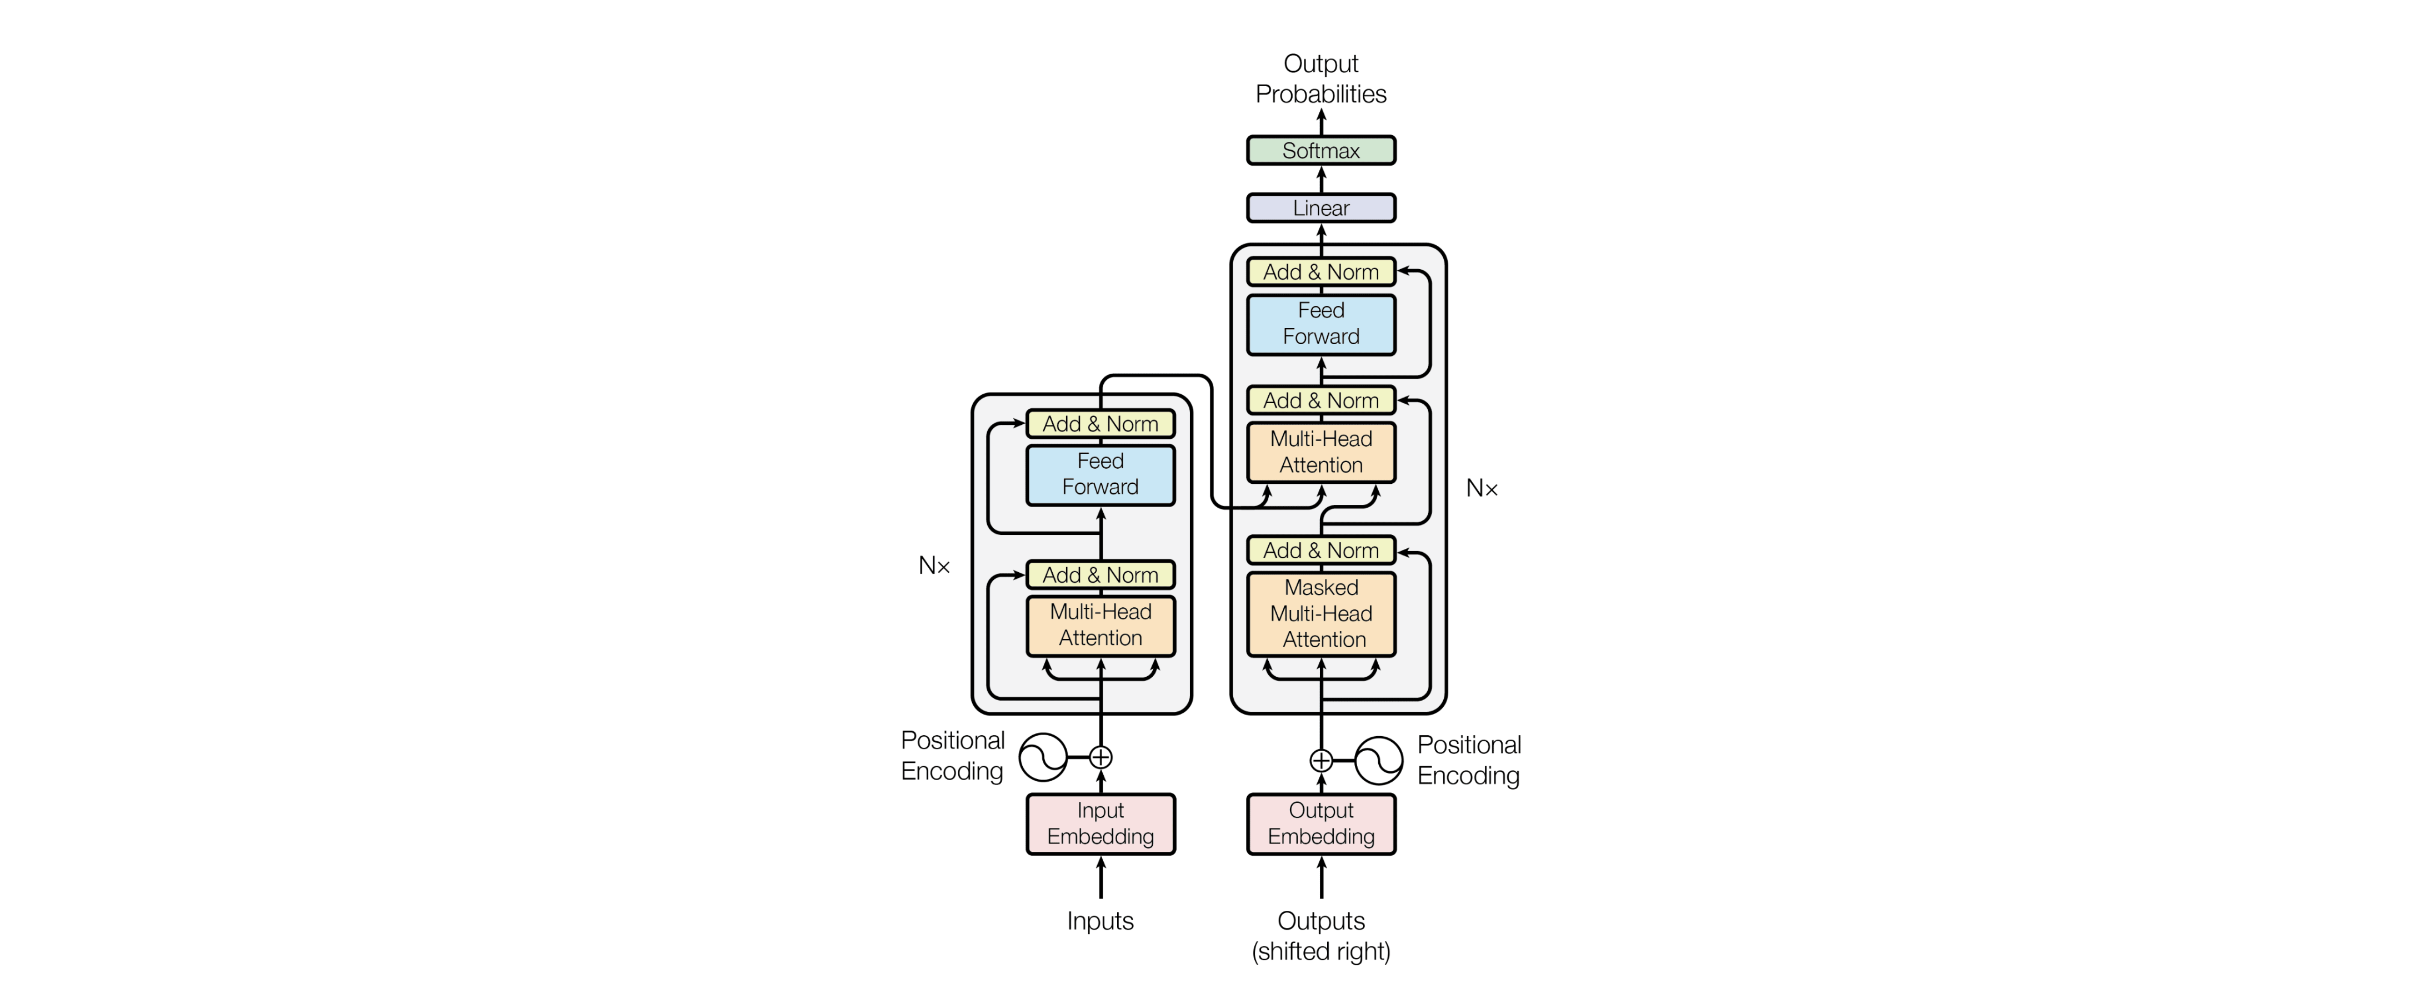

## Token IDs vs Embeddings

Before embeddings, each token is represented by a unique integer ID:

```text
a → 0
b → 1
c → 2
```

These IDs are just labels and carry no meaning.

If `n_embd = 4`, each token is instead represented by a vector of 4 learned numbers:

```text
a → [0.2, -0.8, 1.5, 0.1]
b → [-0.3, 0.7, 0.4, 2.0]
c → [1.1, 0.5, -0.2, 0.9]
```

So, instead of the model working with:

```python
[0, 1, 2]
```

it works with:

```python
[
 [0.2, -0.8, 1.5, 0.1],
 [-0.3, 0.7, 0.4, 2.0],
 [1.1, 0.5, -0.2, 0.9]
]
```

**`n_embd`** is simply the length of the embedding vector for each token.


In [101]:
# now look at the picture you can see the what we have built and what we need to build now
class FeedForward(nn.Module):
  def __init__(self,n_embd):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(n_embd,4*n_embd),
        nn.ReLU(),
        nn.Linear(4*n_embd,n_embd),
        nn.Dropout(0.5)
    )
  def forward(self,x):
    return self.net(x)


In [102]:
# now we need to create the block one complete block
class Block(nn.Module):
  def __init__(self,n_embd,n_head):
    # n_embd: embedding dimension, n_head: the number of heads we'd like
    super().__init__()
    head_size = n_embd // n_head
    self.sa = MultiHeadAttention(n_head,head_size) # sa --> self-attention
    self.ffwd = FeedForward(n_embd)
    self.ln1 = nn.LayerNorm(n_embd)
    self.ln2 = nn.LayerNorm(n_embd)
    # LOOK AT CAREFULLY THERE IS LAYER NORMALISATION AFTER THE MULTHEAD THAT IS WHAT WE ADDED HERE

  def forward(self,x):
    x  = x + self.sa(self.ln1(x))
    x = x + self.ffwd(self.ln2(x))
    return x



# Introducing the Bigram Language Model

To keep things simple, we'll start by building a **Bigram Language Model**—one of the simplest language models.

A **bigram** model predicts the next token using **only the immediately previous token** as context.

Instead of considering the entire sequence of previous tokens, the model looks back **just one token** to make its prediction.

### Example

```text
Input Token   →   Predicted Next Token

"h"           →   "e"
"e"           →   "l"
"l"           →   "l"
"l"           →   "o"
```

Or, in terms of encoded tokens:

```text
[18] → 47
[47] → 56
[56] → 57
[57] → 58
```

### Why start with a Bigram Model?

* It is simple and easy to understand.
* It introduces the core idea of **next-token prediction**.
* It serves as a strong foundation before moving on to the full **Transformer**, which can use much longer contexts through its attention mechanism.

> **Key Idea:** A Bigram Language Model only looks at **one previous token** to predict the next token. Later, we'll replace this limitation with the Transformer's self-attention mechanism, allowing the model to learn from the entire context instead of just the last token.


In [1]:
import torch
import torch.nn as nn # Pre built nueral network layers and model
from torch.nn import functional as F
torch.manual_seed(1337)
class BigramLanguageModel(nn.Module):
  def __init__(self):
    super().__init__()
    # each token directly reads off the logits for the next token from a lookup table
    self.token_embedding_table = nn.Embedding(vocab_size,n_embd)
    self.position_embedding_table = nn.Embedding(block_size,n_embd)
    self.blocks = nn.Sequential(*[Block(n_embd,n_head=n_head) for _ in range(n_layer)])
    self.ln_f = nn.LayerNorm(n_embd)
    self.lm_head = nn.Linear(n_embd,vocab_size)


  def forward(self,idx,targets=None):
    B,T = idx.shape

    # idx and targets are both (B,T) tensor of the integers
    tok_emb = self.token_embedding_table(idx)
    pos_emb = self.position_embedding_table(torch.arange(T,device=device))
    x = tok_emb + pos_emb
    x = self.blocks(x)
    x = self.ln_f(x)
    logits = self.lm_head(x)

    if targets is None:
      loss = None
    else:
      B,T,C = logits.shape
      logits = logits.view(B*T,C)
      targets = targets.view(B*T)
      loss = F.cross_entropy(logits,targets)
    return logits,loss

  def generate(self, idx, max_new_tokens):
    # idx is (B,T) array of indices of current context
    for _ in range(max_new_tokens):

        # Crop context to the last block_size tokens
        idx_cond = idx[:, -block_size:]

        # Get predictions
        logits, loss = self(idx_cond)

        # Focus only on last time step
        logits = logits[:, -1, :]      # (B, vocab_size)

        # Convert to probabilities
        probs = F.softmax(logits, dim=-1)

        # Sample next token
        idx_next = torch.multinomial(probs, num_samples=1)

        # Append to sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

model = BigramLanguageModel()
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

# generate from the model
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))


NameError: name 'vocab_size' is not defined